#### Import

In [1]:
import numpy as np; import pandas as pd; import matplotlib.pyplot as mp; import seaborn as sea; import datetime as dt; import random as r; import math as m; import statistics as st; import mysql.connector as ms; import warnings; warnings.filterwarnings("ignore"); warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy connectable*"); warnings.filterwarnings("ignore", message=".*is_categorical_dtype is deprecated.*"); warnings.filterwarnings("ignore", message="invalid escape sequence.*", category=SyntaxWarning)


#### Data

In [3]:
dbd="Superstore_Sales"


#### Display

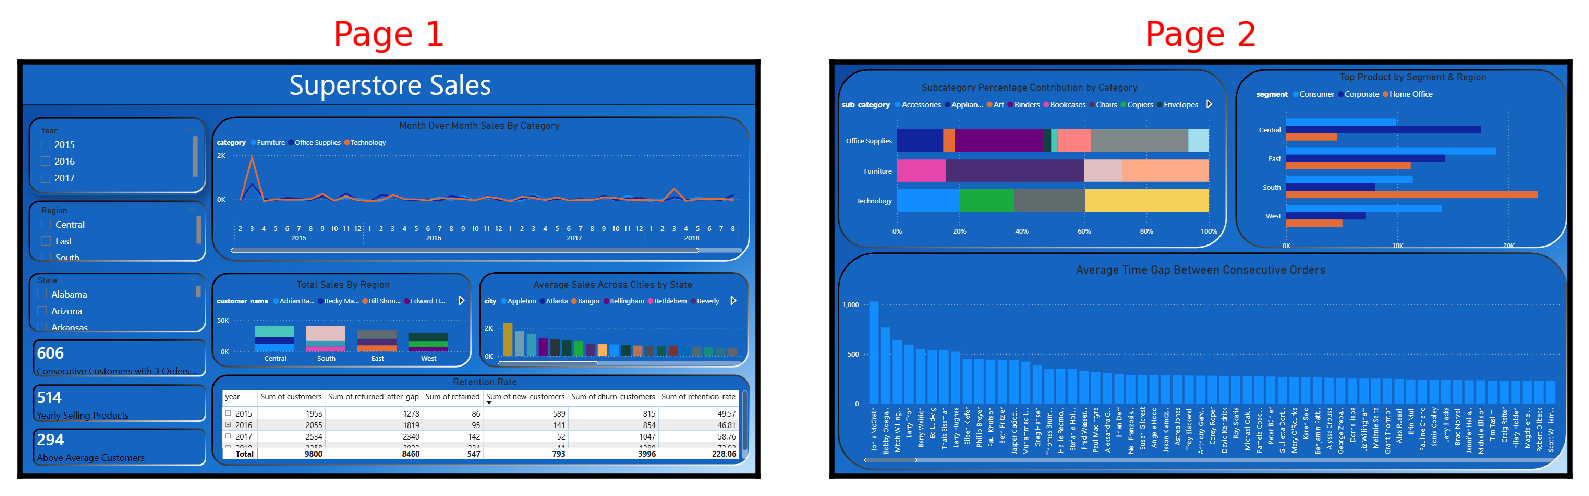

In [4]:
from PIL import Image
import matplotlib.pyplot as mp

image_1 = Image.open(r"Image\Image 1.png")
image_2 = Image.open(r"Image\Image 2.png")
# image_3 = Image.open(r"Image\Image 3.png")

images = [image_1, image_2]
cols = 2
rows = 2
mp.figure(figsize=(10, 7),dpi=200)
mp.subplots_adjust(wspace=0.1, hspace=0)

for i, img in enumerate(images):
    ax = mp.subplot(rows, cols, i + 1)
    rotated = img.rotate(0)
    ax.imshow(rotated, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)
    ax.set_title(f"Page {i+1}",color="red")
mp.show()

#### Insights

#### Views

In [5]:
db = ms.connect(
    host="localhost",
    user="root",
    password="67777777",
    database=dbd)
cur = db.cursor()
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for table in tables:
    print(f"\n===== {table} =====\n")
    df = pd.read_sql(f"SELECT * FROM {table}", con=db)
    print(" ,\n".join(df.columns))


===== 10_renention_rate_month_by_month_based_on_repeat_purchases =====

year ,
month ,
customers ,
new_customers ,
churn_customers ,
returned_after_gap ,
retained ,
retention_rate

===== 1_top_3_customes_in_each_region_based_on_total_sales =====

region ,
customer_name ,
total_sales

===== 2_month_over_month_sales_for_each_category =====

category ,
year ,
month ,
total_sales ,
previous_total_sales ,
month_over_month_sales

===== 3_consecutive_customer_for_increased_3_orders =====

consecutive_customers_for_3_orders

===== 4_city_with_average_sales_in_each_state =====

city ,
state ,
average_sales_each_state

===== 5_percentage_contribution_of_each_subcatory_within_category =====

category ,
sub_category ,
percentage_contribution

===== 6_average_time_gap_between_consecutive_orders_for_customers =====

category ,
average_time_gap_for_customer

===== 7_products_that_generated_sales_in_every_year =====

products_generated_sales_every_year

===== 8_customers_whose_total_sales_are_above_a

In [6]:
query=""" 
CREATE OR REPLACE VIEW train_city AS
select distinct city
from train
"""
cur.execute(query)
data=cur.fetchall()

#### Columns

In [7]:
db = ms.connect(host = "localhost", 
                username = "root", 
                password = "67777777", 
                database = dbd) 
cur = db.cursor()
cur.execute("SHOW TABLES");tables=[t[0] for t in cur.fetchall()];dfs=[];import pandas as pd
for i,table in enumerate(tables,1):
 df=pd.read_sql(f"SELECT * FROM {table}",con=db)
 for col in df.columns:
  if 'date'in col.lower()or'time'in col.lower():df[col]=pd.to_datetime(df[col],errors='coerce')
 temp=pd.DataFrame({'Table':table,'Column':df.columns,'Type':[str(df[c].dtype)for c in df.columns]});temp.index=[i]*len(temp);temp.index.name='index';dfs+=[temp,pd.DataFrame([['','','']],columns=temp.columns,index=[""])]
cn_final=pd.concat(dfs);print(f"\n{'':<8}{'Table':<20}{'Column':30}{'Type'}\n")
for i,table in enumerate(tables,1):
 for _,r in cn_final[cn_final['Table']==table].iterrows():print(f"{i:<5}{r['Table']:<18}{r['Column']:<35}{r['Type']}")
 print()
print("All tables in the database:\n"); 
for table in tables: print(f"{table}")


        Table               Column                        Type

1    10_renention_rate_month_by_month_based_on_repeat_purchasesyear                               int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasesmonth                              int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasescustomers                          int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasesnew_customers                      int64
1    10_renention_rate_month_by_month_based_on_repeat_purchaseschurn_customers                    int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasesreturned_after_gap                 int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasesretained                           int64
1    10_renention_rate_month_by_month_based_on_repeat_purchasesretention_rate                     float64

2    1_top_3_customes_in_each_region_based_on_total_salesregion                             str
2   

#### Table

In [8]:
table="train"
try:display(pd.read_sql(f"select * from {table}", db).pipe(lambda df: df.rename(columns=lambda c: f"{c} (c{df.columns.get_loc(c)+1})").head(3).style.hide(axis="index").set_properties(**{'text-align':'left'}).set_table_styles([{'selector':'th','props':[('text-align','center'),('border','1.5px solid white')]},{'selector':'td','props':[('border','1px solid white')]}])))
except:pass

row_id (c1),order_id (c2),order_date (c3),ship_date (c4),ship_mode (c5),customer_id (c6),customer_name (c7),segment (c8),country (c9),city (c10),state (c11),postal_code (c12),region (c13),product_id (c14),category (c15),sub_category (c16),product_name (c17),sales (c18),postal_code_isnull (c19)
1,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960000,1
2,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.940000,1
3,138688,2017-06-12 00:00:00,2017-06-16 00:00:00,Second Class,13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.620000,1


#### Tables All

In [9]:
from IPython.display import display
import pandas as pd
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for i, table in enumerate(tables, start=1):
    print(f"\n{'='*60}")
    print(f"Table {i}: {table}")
    print(f"{'='*60}")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", con=db)
    df = df.rename(columns={col: f"{col} (c{i+1})" for i, col in enumerate(df.columns)})
    display(df.head(2).style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
    


Table 1: 10_renention_rate_month_by_month_based_on_repeat_purchases


year (c1),month (c2),customers (c3),new_customers (c4),churn_customers (c5),returned_after_gap (c6),retained (c7),retention_rate (c8)
2015,1,77,30,28,47,0,0.000000
2015,2,46,25,23,19,2,4.350000



Table 2: 1_top_3_customes_in_each_region_based_on_total_sales


region (c1),customer_name (c2),total_sales (c3)
Central,Tamara Chand,18437.100000
Central,Adrian Barton,12181.600000



Table 3: 2_month_over_month_sales_for_each_category


...

year (c1)
2017
2016



Table 19: trains


ri (c1),o (c2),od (c3),sd (c4),sm (c5),cid (c6),c (c7),seg (c8),cou (c9),cit (c10),sta (c11),pc (c12),reg (c13),p (c14),cat (c15),sc (c16),pn (c17),s (c18),pc_isnull (c19)
1,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960000,1
2,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.940000,1



Table 20: trains_final


row_id (c1),order_id (c2),order_date (c3),ship_date (c4),ship_mode (c5),customer_id (c6),customer_name (c7),segment (c8),country (c9),city (c10),state (c11),postal_code (c12),region (c13),product_id (c14),category (c15),sub_category (c16),product_name (c17),sales (c18),postal_code_isnull (c19),month (c20),year (c21)
1,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960000,1,11,2017
2,152156,2017-11-08 00:00:00,2017-11-11 00:00:00,Second Class,12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.940000,1,11,2017


#### 1. Find the top 3 customers in each region based on total sales.

region,customer_name,total_sales,regions
Central,Tamara Chand,18437.140000,4
Central,Adrian Barton,12181.600000,4
Central,Becky Martin,10539.900000,4
East,Tom Ashbrook,13723.500000,1
East,Hunter Lopez,10522.550000,1


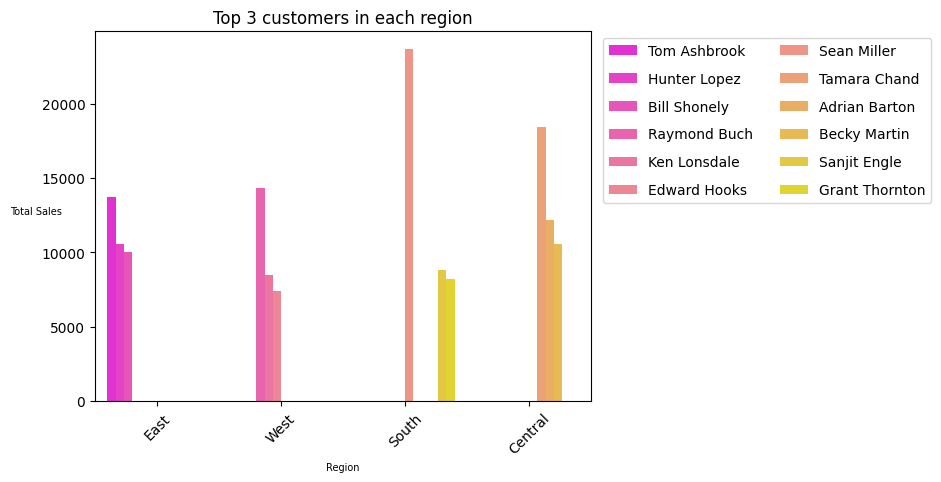

In [10]:
query=""" 
with a as (
select reg , c , sum(s) as ts,
dense_rank() over(partition by reg order by sum(s) desc) as drank
from trains
group by reg,c
)
select reg as region,c as customer_name ,round(ts,2) as total_sales,
case 
when reg="East" then 1
when reg="West" then 2
when reg="North" then 3
else 4
end as regions
from a
where drank<=3
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/1.Top 3 customes in each region based on total sales.csv",index=False)

a=True
b=False
df = df.sort_values(by=["regions","total_sales"], ascending=[a,b])
df = df.reset_index(drop=True)


sea.barplot(data=df,x="region",y="total_sales",hue="customer_name",palette="spring",errorbar=("ci",0))

mp.xlabel("Region",fontsize=7,rotation=0)
mp.ylabel("Total Sales",fontsize=7,rotation=0)
mp.title("Top 3 customers in each region")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0.7,0),ncols=2,labelspacing=1)
mp.show()

#### 2. Calculate month-over-month sales growth percentage for each category.

category,year,month,total_sales,previous_total_sales,month_over_month_sales
Furniture,2015,1,6217.280000,nan,nan
Furniture,2015,2,1839.660000,6217.280000,-70.410000
Furniture,2015,3,14243.390000,1839.660000,674.240000
Furniture,2015,4,7944.830000,14243.390000,-44.220000
Furniture,2015,5,6912.790000,7944.830000,-12.990000


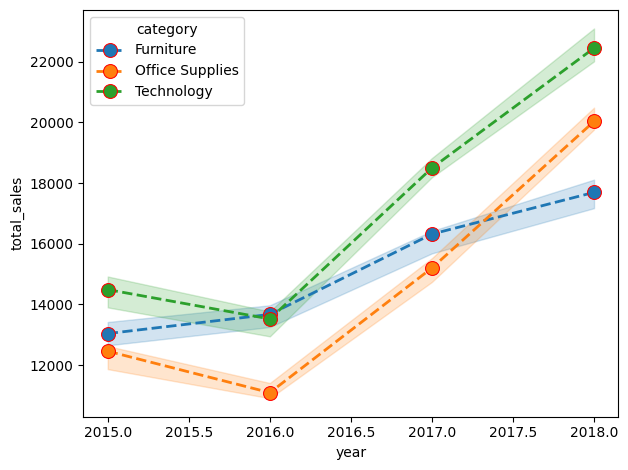

In [11]:
query=""" 
with a as (
select  cat,
sum(s) as cs,
extract(year_month from od) as m,
extract(month from od) as mm,
extract(year from od) as y,
lag(sum(s)) over(partition by cat order by extract(year_month from od)) as ps
from trains
group by cat,m,y,mm
)
select cat as category,y as year,mm as month,round(cs,2) as total_sales,round(ps,2) as previous_total_sales,round(100.0*(cs-ps)/ps,2) as month_over_month_sales
from a
order by cat,m
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/2.Month Over Month sales for each category.csv",index=False)


sea.lineplot(data=df,x="year",y="total_sales",hue="category",marker="o",markersize=10,markeredgecolor="red",linestyle="dashed",linewidth=2,errorbar=("ci",12))

# sea.barplot(data=df,x="category",y="total_sales",hue="year",palette="spring",errorbar=("ci",0),ec="red")

# mp.pie(df["total_sales"],labels=df["category"],shadow=True,autopct="%.2f%%",startangle=45)

# sea.scatterplot(data=df,x="category",y="total_sales",hue="year",s=50,alpha=1)

# sea.histplot(data=df,x="total_sales",hue="year",palette="hot",bins=30,discrete=False,edgecolor="darkblue")

# sea.boxplot(data=df,x="category",y="total_sales",orient="vertical",fliersize=7)

# sea.violinplot(data=df,x="total_sales")

# mp.stem(df["total_sales"],df["year"],bottom=50,linefmt="--",markerfmt="*",basefmt="o",orientation="vertical")

# mp.stackplot(df["category"],df["total_sales"])

# mp.step(df["category"],df["total_sales"],where="mid")

# a=sea.FacetGrid(data=df,col="year",hue="year",height=3)
# a.map(sea.barplot,"category","total_sales")

# sea.relplot(data=df,x="category",y="total_sales",col="year",hue="year",kind="line",linewidth=3)

# sea.swarmplot(data=df,x="category",y="total_sales",hue="year")

# sea.kdeplot(data=df,x="total_sales",hue="category",multiple="stack")

mp.tight_layout()
mp.show()


#### 3. Find customers whose sales increased consecutively for at least 3 orders.

consecutive_customers_for_3_orders
606


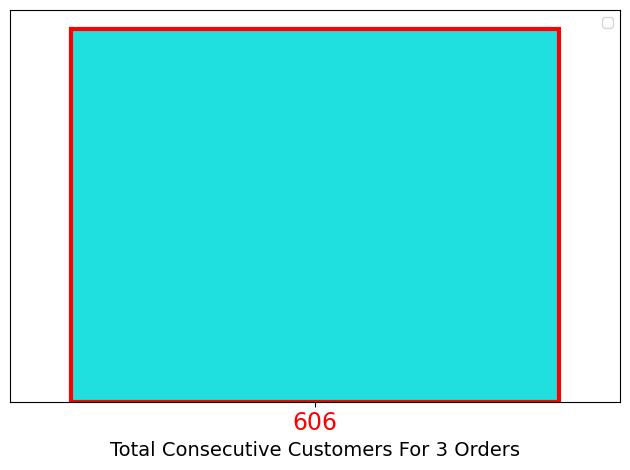

In [12]:
query=""" 
with a as (
select c,s,
lag(s,1) over(partition by cid order by od) as ps1,
lag(s,2) over(partition by cid order by od) as ps2
from trains
order by c,od
), b as (
select distinct c 
from a
where s>ps1 and ps1>ps2
)
select count(*) as consecutive_customers_for_3_orders from b
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/3.Consecutive customer for increased 3 orders.csv",index=False)


sea.countplot(data=df,x="consecutive_customers_for_3_orders",edgecolor="red",color="aqua",linewidth=3)
mp.xlabel("Total Consecutive Customers For 3 Orders",fontsize=14,rotation=0)
mp.ylabel("")
mp.xticks(rotation=0,color="red",fontsize=17)
mp.yticks([])
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 4. Identify the city with the highest average order value (sales) in each state.

city,state,average_sales_each_state
Mobile,Alabama,496.640000
Gilbert,Arizona,278.160000
Texarkana,Arkansas,327.120000
Burbank,California,1082.390000
Longmont,Colorado,305.030000


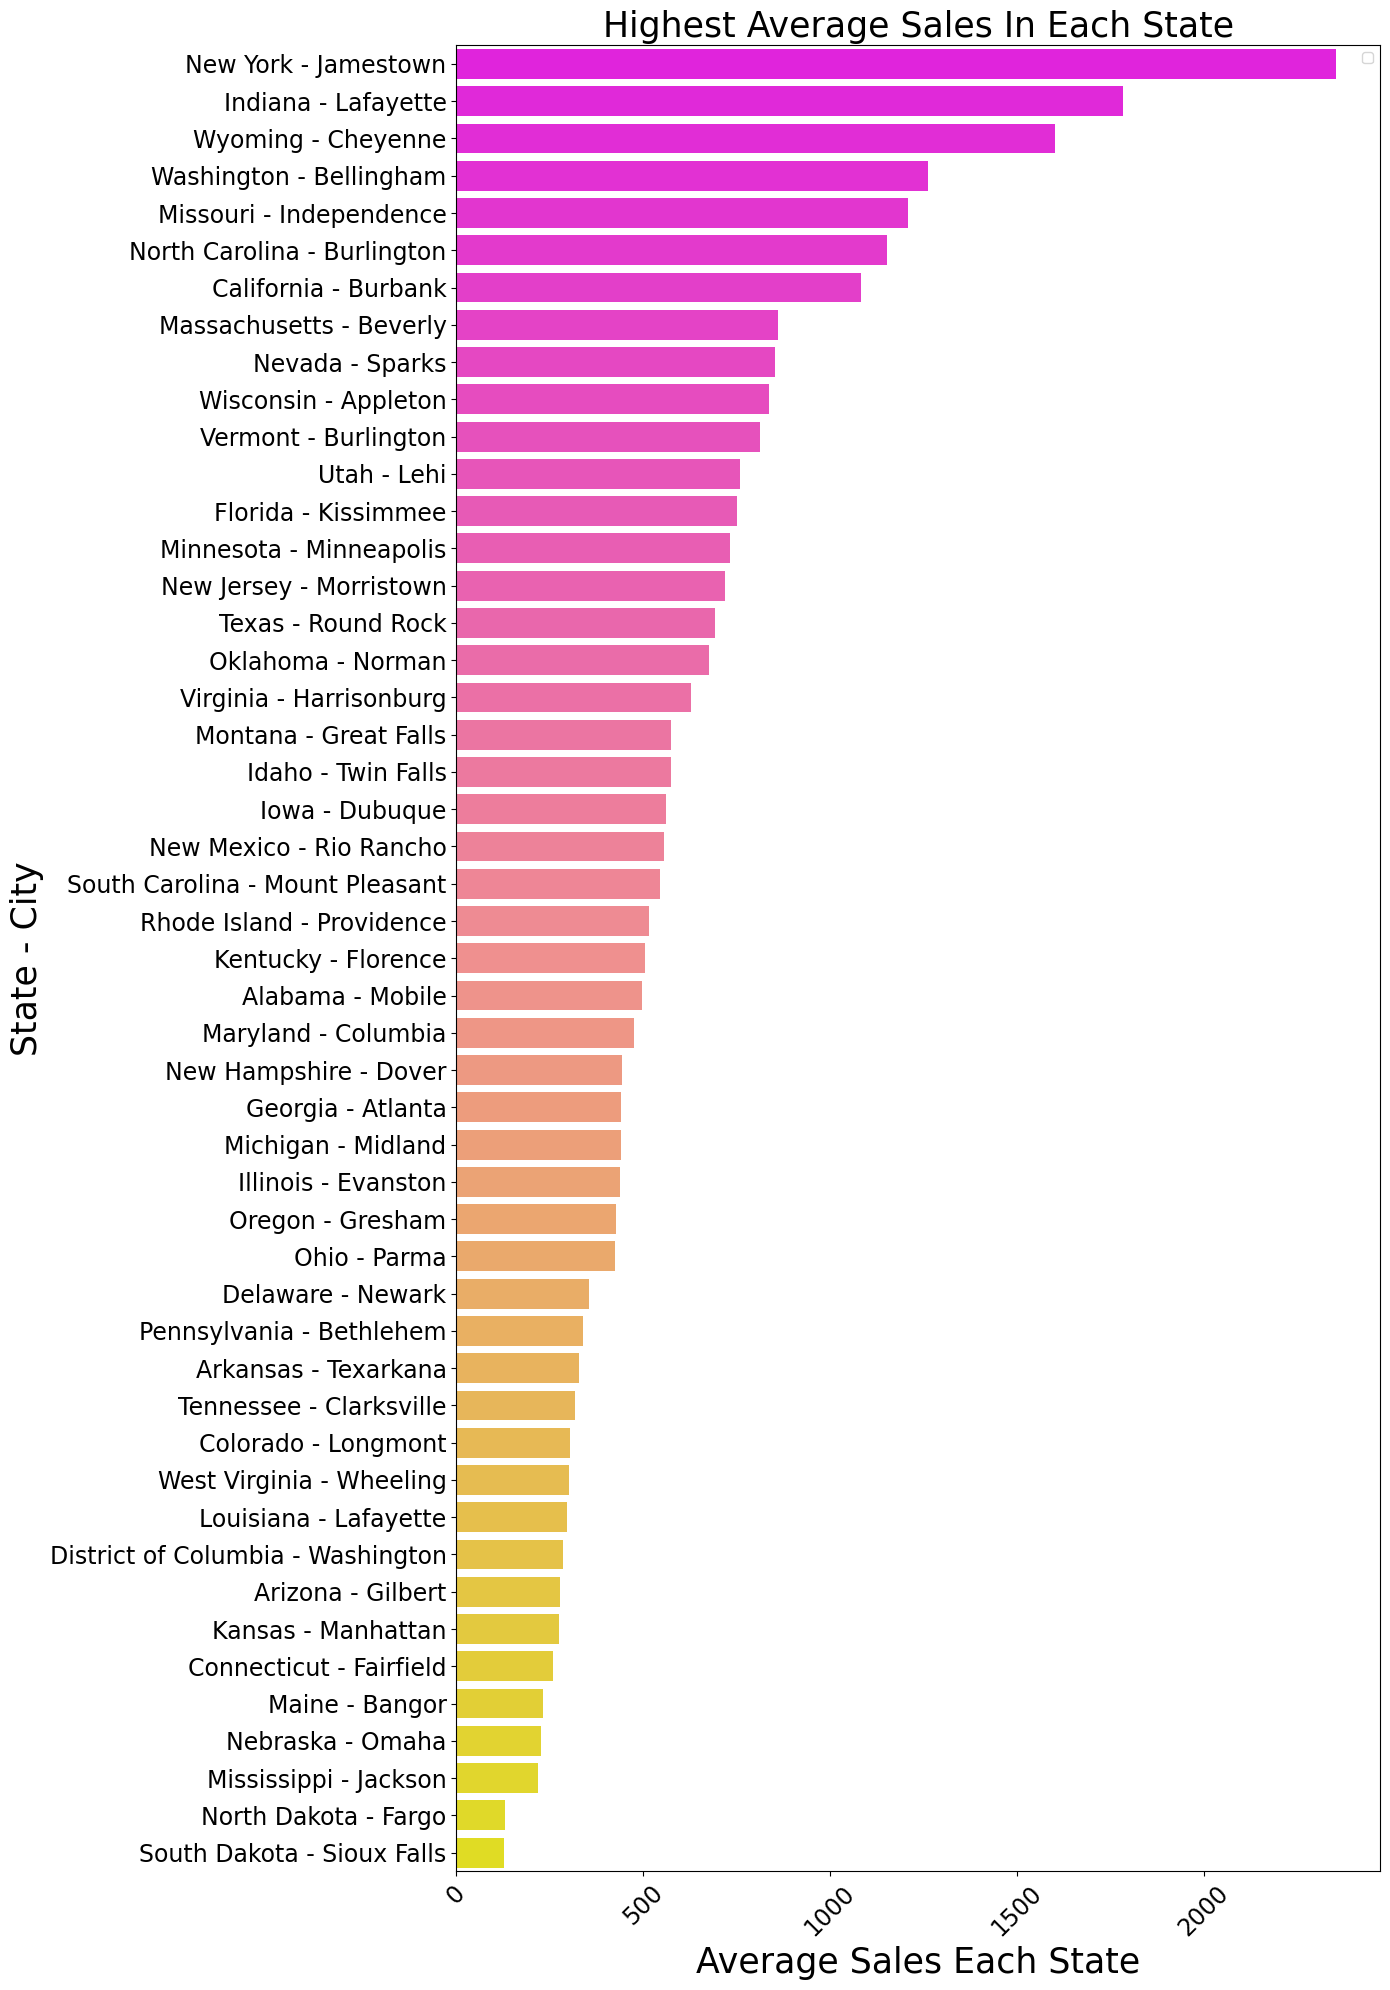

In [13]:
query=""" 
with a as (
select sta,cit,avg(s) as os 
from trains
group by sta,cit
), b as (
select sta,cit,os,
row_number() over(partition by sta order by os desc) as drank
from a
order by sta,os desc
)
select cit as city,sta as state,round(os,2) as average_sales_each_state 
from b
where drank=1
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/4.City with average sales in each state.csv",index=False)
a=True
b=False
df = df.sort_values(by=["average_sales_each_state"], ascending=[b])
df = df.reset_index(drop=True)
df.columns = df.columns.str.strip()

df["state_city"] = df["state"] + " - " + df["city"]
mp.figure(figsize=(14,20))

sea.barplot(data=df,x="average_sales_each_state",y="state_city",palette="spring")

mp.xlabel("Average Sales Each State",fontsize=25,rotation=0)
mp.ylabel("State - City",fontsize=25,rotation=90)
mp.title("Highest Average Sales In Each State",fontsize=25)
mp.xticks(rotation=45,fontsize=17)
mp.yticks(rotation=0,fontsize=17)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 5. Find the percentage contribution of each sub_category within its category.

category,sub_category,percentage_contribution
Furniture,Chairs,44.300000
Furniture,Tables,27.830000
Furniture,Bookcases,15.620000
Furniture,Furnishings,12.240000
Office Supplies,Storage,31.090000


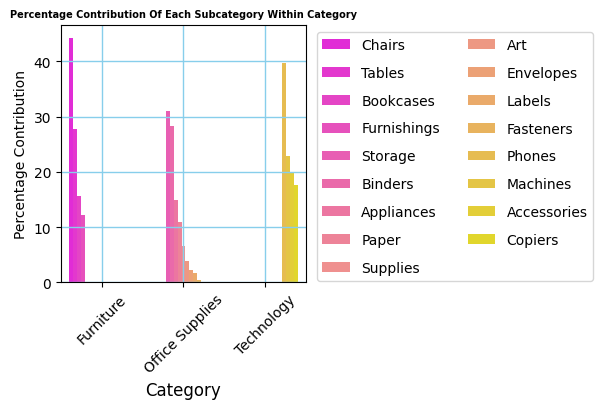

In [14]:
query=""" 
with a as (
select cat,sc,
sum(s) as scs,
sum(sum(s)) over(partition by cat) as cats
from trains
group by cat,sc
)
select cat as category,sc as sub_category,round(100.0*scs/cats,2) as percentage_contribution
from a
order by cat,percentage_contribution desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/5.Percentage contribution of each subcatory within category.csv",index=False)

mp.figure(figsize=(45, 4.2))

sea.barplot(data=df,x="category",y="percentage_contribution",hue="sub_category",palette="spring",errorbar=("ci",0))

mp.xlabel("Category",fontsize=12,rotation=0)
mp.ylabel("Percentage Contribution",fontsize=10,rotation=90)
mp.title("Percentage Contribution Of Each Subcategory Within Category",fontsize=7,fontweight="bold")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,1.2,0),ncols=2,labelspacing=1)
mp.grid(axis="both",linewidth=1,color="skyblue")
mp.tight_layout()
mp.show()

#### 6. Calculate the average time gap between consecutive orders for each customer.

customer_name,average_time_gap_for_customer
Aaron Bergman,199.20
Aaron Hawkins,133.60
Aaron Smayling,129.33
Adam Bellavance,45.82
Adam Hart,58.21


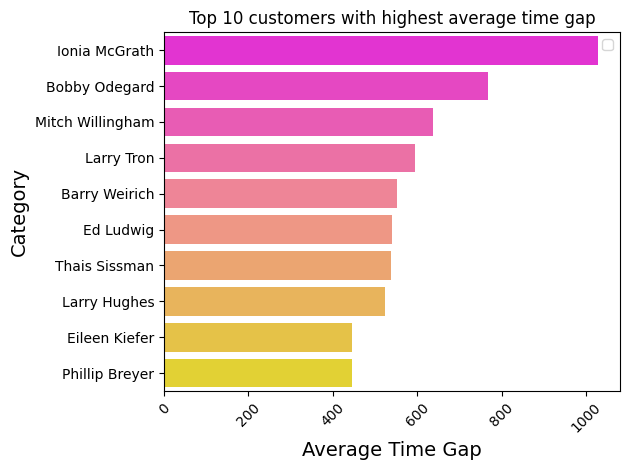

In [15]:
query=""" 
with a as (
select c,od,
lag(od) over(partition by cid order by od) as pd
from trains
order by c,od
),b as (
select c ,timestampdiff(day,pd,od) as td
from a
where pd is not null
)
select c as customer_name,round(avg(td),2) as average_time_gap_for_customer 
from b 
group by c
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/6.Average time gap between consecutive orders for customers.csv",index=False)

a=True
b=False
df = df.sort_values(by=["average_time_gap_for_customer"], ascending=[b]).head(10)
df = df.reset_index(drop=True)

sea.barplot(data=df,x="average_time_gap_for_customer",y="customer_name",palette="spring",errorbar=("ci",0))

mp.xlabel("Average Time Gap",fontsize=14,rotation=0)
mp.ylabel("Category",fontsize=14,rotation=90)
mp.title("Top 10 customers with highest average time gap")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 7. Find products that generated sales in every year available in the dataset.

products_generated_sales_every_year
514


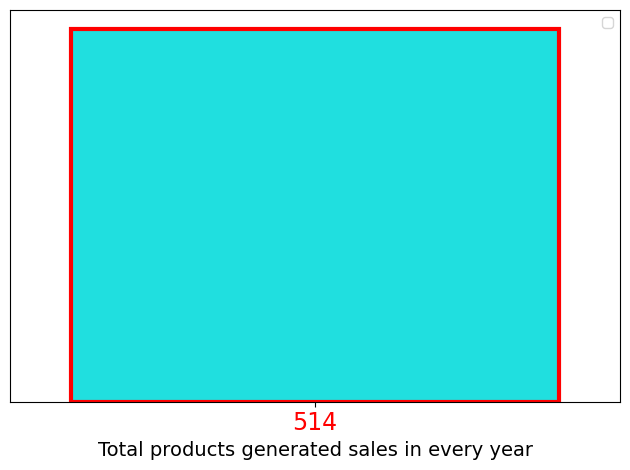

In [16]:
query=""" 
with a as (
select p,pn,count(distinct extract(year from od)) as py
from trains
where s is not null
group by p,pn
), b as (
select count(distinct extract(year from od)) as ty
from trains
where s is not null
)
select count(distinct p) as products_generated_sales_every_year from a 
join b 
on a.py=b.ty
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/7.Products that generated sales in every year.csv",index=False)

sea.countplot(data=df,x="products_generated_sales_every_year",edgecolor="red",color="aqua",linewidth=3)
mp.xlabel("Total products generated sales in every year",fontsize=14,rotation=0)
mp.ylabel("")
mp.xticks(rotation=0,color="red",fontsize=17)
mp.yticks([])
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 8. Identify customers whose total sales are above the overall average customer sales.

customers_above_average_sales
294


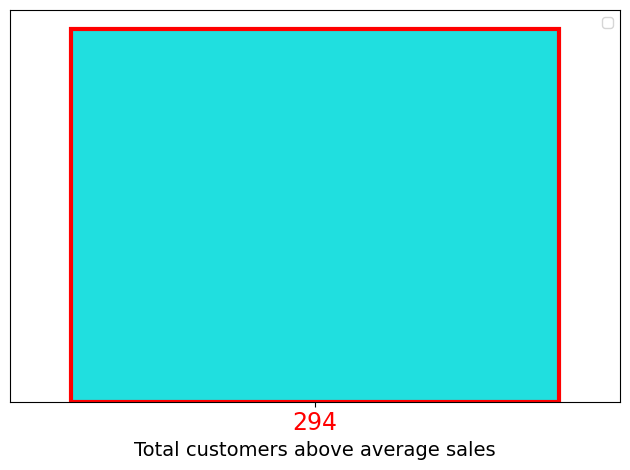

In [17]:
query=""" 
with a as (
select c,
sum(s) as ts
from trains
group by c
) , b as (
select avg(ts) as ac
from a
)
select count(distinct c) as customers_above_average_sales
from a join b
on a.ts>b.ac
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/8.Customers whose total sales are above average sales.csv",index=False)

sea.countplot(data=df,x="customers_above_average_sales",edgecolor="red",color="aqua",linewidth=3)
mp.xlabel("Total customers above average sales",fontsize=14,rotation=0)
mp.ylabel("")
mp.xticks(rotation=0,color="red",fontsize=17)
mp.yticks([])
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 9. Find the top-selling product in each segment and region combination.


segment,region,product_id,total_sales
Consumer,Central,10000545,9892.740000
Consumer,East,10004722,18899.950000
Consumer,South,10001127,11374.930000
Consumer,West,10004722,13999.960000
Corporate,Central,10004722,17499.950000


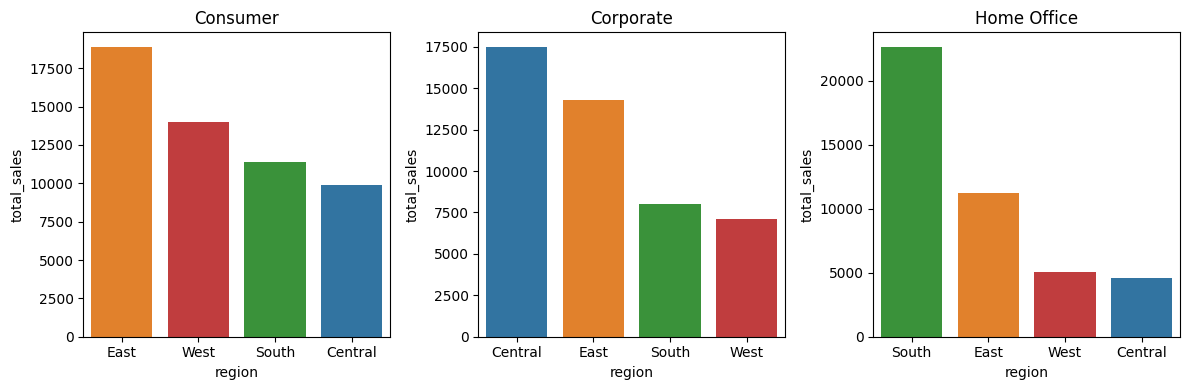

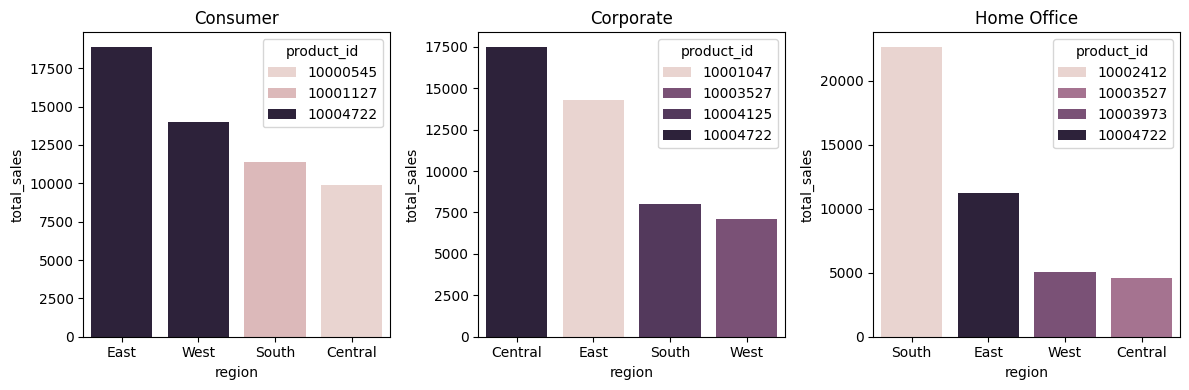

In [18]:
query=""" 
with a as (
select seg ,reg,p,sum(s) as ts
from trains
group by seg,reg,p
order by seg,reg
), b as (
select seg,reg,p, ts,
dense_rank() over(partition by seg,reg order by ts desc) as drank
from a
)
select seg as segment,reg as region,p as product_id,round(ts,2) as total_sales from b 
where drank=1
order by seg,reg
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/9.Selling top product in each sement and region combination.csv",index=False)

segments = df["segment"].unique()
region_order = df["region"].unique()
fig, axes = mp.subplots(1, len(segments), figsize=(12,4))
for ax, seg in zip(axes, segments):
    d = df[df["segment"] == seg].sort_values("total_sales", ascending=False)
    sea.barplot(data=d,
                x="region",
                y="total_sales",
                hue="region",
                hue_order=region_order,
                order=d["region"],
                ax=ax)
    ax.set_title(seg)
mp.tight_layout()
mp.show()
segments = df["segment"].unique()
region_order = sorted(df["product_id"].unique())
fig, axes = mp.subplots(1, len(segments), figsize=(12,4))
for ax, seg in zip(axes, segments):
    d = df[df["segment"] == seg].sort_values("total_sales", ascending=False)
    sea.barplot(data=d,
                x="region",
                y="total_sales",
                hue="product_id",
                hue_order=region_order,
                order=d["region"],
                ax=ax)
    ax.set_title(seg)
mp.tight_layout()
mp.show()



#### 10. Calculate customer retention rate month-by-month based on repeat purchases.

year,month,customers,new_customers,churn_customers,returned_after_gap,retained,retention_rate
2015,1,77,30,28,47,0,0.00
2015,2,46,25,23,19,2,4.35
2015,3,154,63,63,87,4,2.60
2015,4,130,53,55,73,4,3.08
2015,5,121,55,61,60,6,4.96


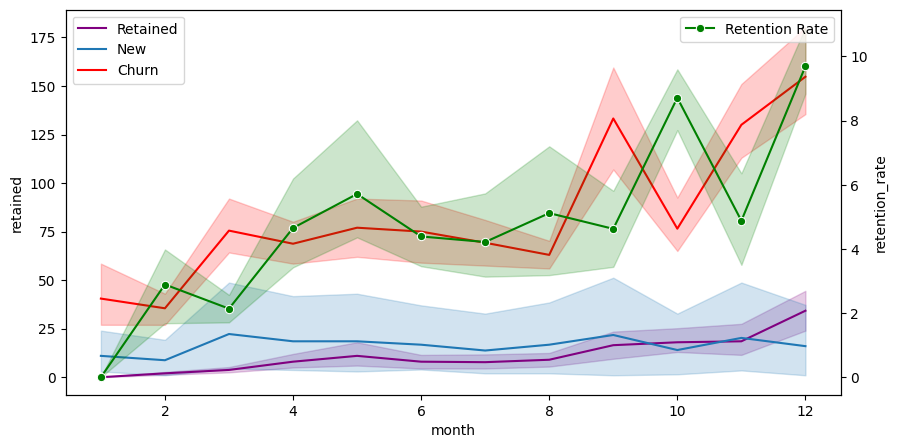

In [19]:
query=""" 
with a as (
select extract(year_month from od) as m,c,extract(year from od) as y,extract(month from od) as mm
from trains
) , b as (
select m,c,y,mm,
lag(m) over(partition by c order by m) as pm,
lead(m) over(partition by c order by m) as nm
from a
) , c as (
select m,count(c) as customers,y,mm,
count(
case
when m-pm=1 then c
end) as retained ,
100.0*count(
case when m-pm=1 then c 
end
)/count(c) as retention_rate,
count(
case 
when pm is null then c
end
) as new_customers,
count(
case 
when nm is null or nm-m>1 then c 
end
) as churn_customers
from b
group by m,y,mm
order by m
)
select y as year,mm as month,customers as customers,new_customers as new_customers,churn_customers as churn_customers,customers-(new_customers+retained) as returned_after_gap,retained as retained,round(retention_rate,2) as retention_rate
from c
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df.to_csv(r"Table 3 - Final/10.Renention rate month by month based on repeat purchases.csv",index=False)

fig, ax1 = mp.subplots(figsize=(10,5))
sea.lineplot(data=df,
             x="month",
             y="retained",
             label="Retained",
             color="purple",
             ax=ax1)
sea.lineplot(data=df,
             x="month",
             y="new_customers",
             label="New",
             ax=ax1)
sea.lineplot(data=df,
             x="month",
             y="churn_customers",
             label="Churn",
             color="red",
             ax=ax1)
ax2 = ax1.twinx()
sea.lineplot(data=df,
             x="month",
             y="retention_rate",
             label="Retention Rate",
             c="green",
             marker="o",
             ax=ax2)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
mp.show()